In [1]:
%env HF_HOME=data/cache
%env TORCH_HOME=data/cache
%cd ../
%pwd

env: HF_HOME=data/cache
env: TORCH_HOME=data/cache
/home/songlin/workspace/projects/SIMPLE


/home/songlin/workspace/projects/SIMPLE/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


'/home/songlin/workspace/projects/SIMPLE'

In [12]:
import os
import rlds
import numpy as np
import json
import tensorflow as tf
import tensorflow_datasets as tfds
from PIL import Image

tf.config.set_visible_devices([], "GPU")

In [3]:
data_dir = "data/vlt-renders.fr3-all-37312-frontstereo+wrist+side-randall-obj63-test"

In [4]:
import tensorflow_datasets as tfds
from simple.datasets.rlds import get_episode_rlds as get_episode
builder = tfds.builder_from_directory(data_dir)
dataset = builder.as_dataset(split='train')
num_episodes = dataset.cardinality().numpy()
print(f"loaded {num_episodes} episodes.")

loaded 52 episodes.


In [5]:
episode = next(iter(dataset))

In [6]:
environment_config = json.loads(episode['environment_config'].numpy().decode("utf-8"))
task_id = episode["uuid"].numpy().decode("utf-8")
task_id

'63_p000_726833a6-ab5e-4a2b-8202-754907275391'

In [7]:
environment_config["object_info"]

[{'id': 63,
  'name': 'white_facewash_0',
  'position': [0.37960024580323, 0.04679027468529995, 0.09386022453408306],
  'orientation': [0.21428299076627821,
   -0.2211941659293704,
   0.6794420505858947,
   -0.6659687986104932],
  'bTarget': True},
 {'id': 47,
  'name': 'white_mouse_0',
  'position': [0.3242122562701216, 0.22967597149844438, 0.021305029612934196],
  'orientation': [0.5989765516760179,
   0.6908737813418797,
   0.381447704048414,
   0.13571351396553225],
  'bTarget': False},
 {'id': 44,
  'name': 'black_and_green_bottle_0',
  'position': [0.3258793879115626, -0.10171914377540728, 0.08396687690608327],
  'orientation': [0.6630189336293277,
   -0.6622417390984418,
   0.24440375923116908,
   -0.24921592067637435],
  'bTarget': False},
 {'id': 61,
  'name': 'cylinder_white_bottle_0',
  'position': [0.44111659839301476, -0.17792950783665984, 0.081521155913196],
  'orientation': [0.04844710824018404,
   0.04897078766344985,
   0.7047458670486649,
   0.7061076423156821],
  'bT

In [8]:
steps = list(episode["steps"])

# print(steps[0]["observation"]["rgb_front_stereo_left"].keys())

observatrions = [step["observation"]["rgb_front_stereo_left"] for step in steps]

for i, image in enumerate(observatrions):
    print(i, image.shape, image.numpy().max())
    break


0 (360, 640, 3) 255


In [13]:
np.set_printoptions(precision=3, suppress=True)

In [17]:
for idx, step in enumerate(steps):
    action = step["action"]
    # print(action.keys()); break
    # break
    print(idx, action["joint_positions"].numpy(), action["gripper"].numpy())

0 [-0.    -1.302 -0.    -2.506 -0.     1.     0.   ] [0.]
1 [ 0.02  -1.168  0.007 -2.549 -0.053  1.182  0.088] [0.]
2 [ 0.029 -1.11   0.01  -2.567 -0.077  1.262  0.127] [0.]
3 [ 0.04  -1.045  0.013 -2.586 -0.104  1.349  0.171] [0.]
4 [ 0.051 -0.974  0.017 -2.606 -0.132  1.443  0.218] [0.]
5 [ 0.063 -0.897  0.021 -2.626 -0.163  1.541  0.269] [0.]
6 [ 0.069 -0.857  0.024 -2.635 -0.178  1.592  0.294] [0.]
7 [ 0.076 -0.817  0.026 -2.644 -0.194  1.643  0.321] [0.]
8 [ 0.082 -0.776  0.028 -2.653 -0.21   1.695  0.347] [0.]
9 [ 0.088 -0.734  0.03  -2.661 -0.226  1.747  0.374] [0.]
10 [ 0.095 -0.692  0.032 -2.669 -0.242  1.798  0.4  ] [0.]
11 [ 0.101 -0.65   0.034 -2.676 -0.258  1.849  0.427] [0.]
12 [ 0.107 -0.609  0.037 -2.682 -0.274  1.899  0.453] [0.]
13 [ 0.114 -0.567  0.039 -2.689 -0.29   1.949  0.479] [0.]
14 [ 0.12  -0.527  0.041 -2.694 -0.305  1.998  0.504] [0.]
15 [ 0.131 -0.448  0.045 -2.704 -0.335  2.09   0.553] [0.]
16 [ 0.142 -0.374  0.049 -2.712 -0.362  2.176  0.598] [0.]
17 [ 0.

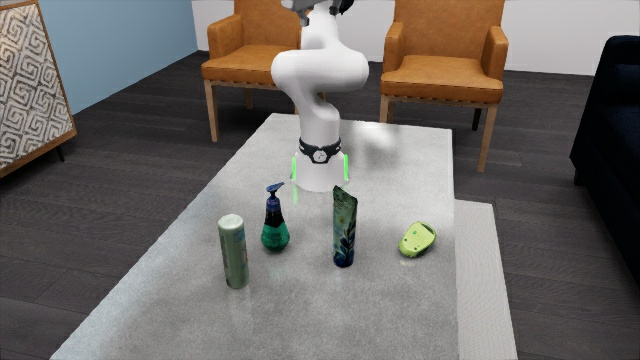

In [ ]:
Image.fromarray(observatrions[0].numpy())